In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/vikrishnan/boston-house-prices/housing.csv",
    delim_whitespace=True,
    header=None
)

df.head()

/tmp/ipykernel_58/3194983430.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
df.columns = [
    'CRIM',
    'ZN',
    'INDUS',
    'CHAS',
    'NOX',
    'RM',
    'AGE',
    'DIS',
    'RAD',
    'TAX',
    'PTRATIO',
    'B',
    'LSTAT',
    'MEDV'
]

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

Dataset Shape:
(506, 14)

Missing Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memor

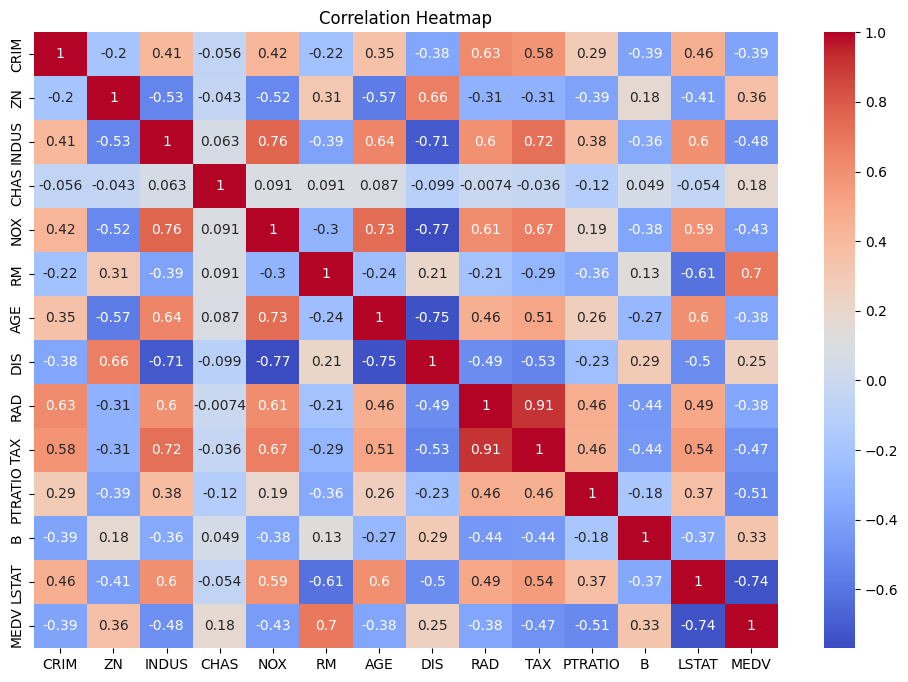

In [5]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

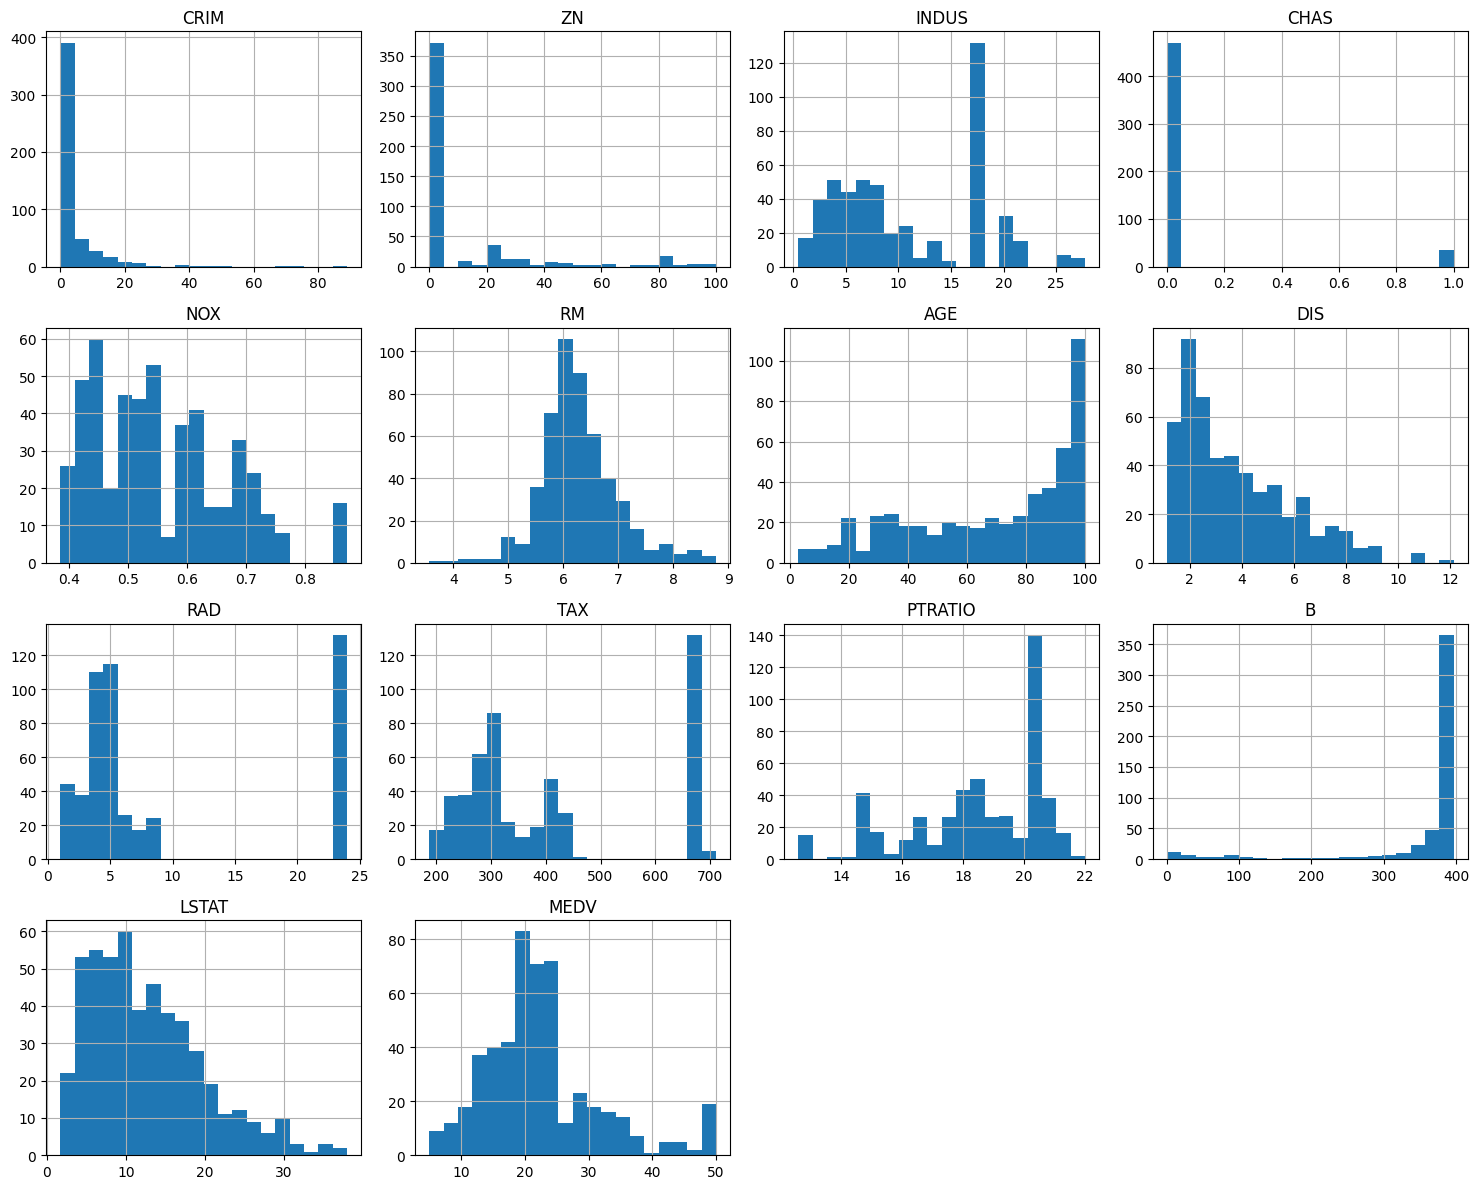

In [6]:
df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()
plt.show()

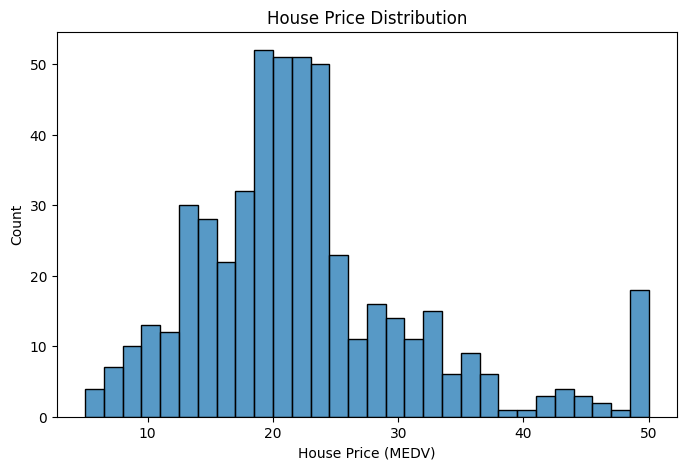

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['MEDV'],
    bins=30
)

plt.title("House Price Distribution")
plt.xlabel("House Price (MEDV)")
plt.show()

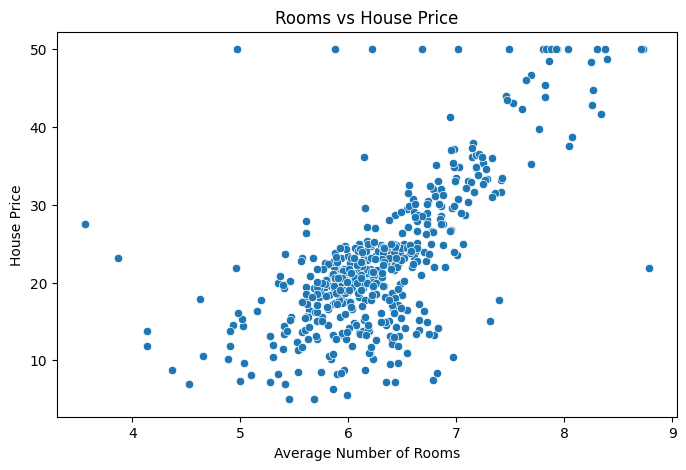

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['RM'],
    y=df['MEDV']
)

plt.title("Rooms vs House Price")
plt.xlabel("Average Number of Rooms")
plt.ylabel("House Price")
plt.show()

In [9]:
X = df.drop('MEDV', axis=1)

y = df['MEDV']

print(X.shape)
print(y.shape)

(506, 13)
(506,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (404, 13)
Testing Shape: (102, 13)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [12]:
model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [14]:
y_pred = model.predict(
    X_test_scaled
)

print(y_pred[:10])

[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992 23.25442929
 17.66253818 14.34119    23.01320703 20.63245597]


In [15]:
mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Squared Error: 24.291119474973513
Root Mean Squared Error: 4.928602182665336
R² Score: 0.668759493535632


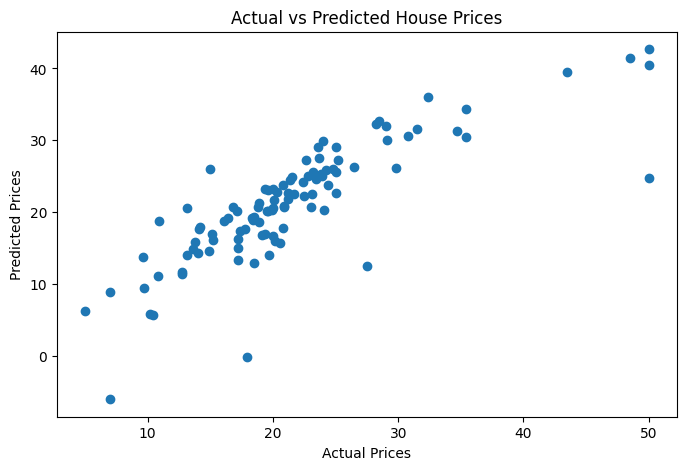

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title(
    "Actual vs Predicted House Prices"
)

plt.show()

In [17]:
new_house = pd.DataFrame({
    'CRIM': [0.03],
    'ZN': [0.0],
    'INDUS': [7.07],
    'CHAS': [0],
    'NOX': [0.469],
    'RM': [6.5],
    'AGE': [70],
    'DIS': [4.5],
    'RAD': [2],
    'TAX': [242],
    'PTRATIO': [17.8],
    'B': [396.9],
    'LSTAT': [9.5]
})

# Scale input
new_house_scaled = scaler.transform(
    new_house
)

# Predict
predicted_price = model.predict(
    new_house_scaled
)

print(
    "Predicted House Price:",
    predicted_price[0]
)

Predicted House Price: 26.081137566733638


In [18]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
173,23.6,28.996724
274,32.4,36.025565
491,13.6,14.816944
72,22.8,25.031979
452,16.1,18.769880
76,20.0,23.254429
316,17.8,17.662538
140,14.0,14.341190
471,19.6,23.013207
500,16.8,20.632456


In [19]:
comparison['Error'] = abs(
    comparison['Actual Price']
    - comparison['Predicted Price']
)

comparison.head(10)

,Actual Price,Predicted Price,Error
173,23.6,28.996724,5.396724
274,32.4,36.025565,3.625565
491,13.6,14.816944,1.216944
72,22.8,25.031979,2.231979
452,16.1,18.769880,2.669880
76,20.0,23.254429,3.254429
316,17.8,17.662538,0.137462
140,14.0,14.341190,0.341190
471,19.6,23.013207,3.413207
500,16.8,20.632456,3.832456
